In [80]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
from datetime import timedelta
import matplotlib.dates as mdates
import numpy as np
import os

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [84]:
method = "exact"

ekdf = pd.read_csv("../results/ek-estimate-" + method + ".csv")

bejkdf = pd.read_csv("../results/bejk-estimate-" + method + ".csv")

krugmandf = pd.read_csv("../results/krugman-estimate-" + method + ".csv")

melitzdf = pd.read_csv("../results/melitz-estimate-" + method + ".csv")


In [85]:
df.head()

,θ,J,p10,p90,Jpercentile,model,method,year
0,4.191993,3.175350e-16,4.042928,4.334476,0.27,ek,exact,2004
1,3.932604,1.224627e-15,3.804102,4.067938,0.29,ek,exact,2011
2,4.248842,2.103586e-14,4.113645,4.389972,0.77,ek,exact,2017


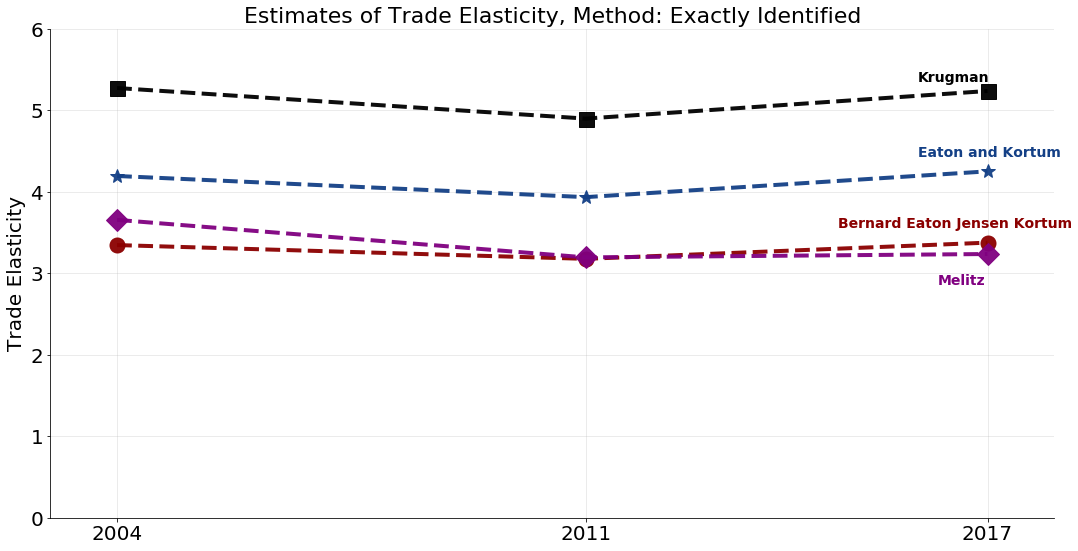

In [87]:
fig, ax = plt.subplots(figsize = (18,9))

mike_blue = tuple(np.array([20, 64, 134]) / 255)

markersize = 15

ax.plot(ekdf["year"], ekdf["θ"], alpha = 0.95, color = mike_blue, linewidth = 4, linestyle= "--",
       marker='*', markersize = markersize, label = "Eaton and Kortum")

ax.plot(bejkdf["year"], bejkdf["θ"], alpha = 0.95, color = "darkred", linewidth = 4, linestyle= "--",
       marker='o', markersize = markersize, label = "Bernard Eaton Jensen Kortum")

ax.plot(krugmandf["year"], krugmandf["θ"], alpha = 0.95, color = "black", linewidth = 4, linestyle= "--",
       marker='s', markersize = markersize, label = "Krugman")

ax.plot(melitzdf["year"], melitzdf["θ"], alpha = 0.95, color = "purple", linewidth = 4, linestyle= "--",
       marker='D', markersize = markersize, label = "Melitz")

ax.tick_params(axis='x', labelsize=20)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=20)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.set_ylim(0.0, 6.0)

# Set x-axis ticks: specific years (2004, 2011, 2017) plus every 5 years
ax.set_xlim(2003, 2018)

# Set x-axis ticks to show specific years
ax.set_xticks([2004, 2011, 2017])


ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)

ax.annotate("Eaton and Kortum", 
           xy=(ekdf["year"].iloc[-1], ekdf["θ"].iloc[-1]), 
           xytext=(-70, 15), textcoords='offset points',
           fontsize=14, color=mike_blue, weight='bold')

ax.annotate("Bernard Eaton Jensen Kortum", 
           xy=(bejkdf["year"].iloc[-1], bejkdf["θ"].iloc[-1]), 
           xytext=(-150, 15), textcoords='offset points',
           fontsize=14, color="darkred", weight='bold')

ax.annotate("Krugman", 
           xy=(krugmandf["year"].iloc[-1], krugmandf["θ"].iloc[-1]), 
           xytext=(-70, 10), textcoords='offset points',
           fontsize=14, color="black", weight='bold')

ax.annotate("Melitz", 
           xy=(melitzdf["year"].iloc[-1], melitzdf["θ"].iloc[-1]), 
           xytext=(-50, -30), textcoords='offset points',
           fontsize=14, color="purple", weight='bold')

ax.set_ylabel('Trade Elasticity', fontsize = 20)

if method == "over":
    ax.set_title("Estimates of Trade Elasticity, Method: " + method.capitalize() + " Identified", fontsize = 22, loc= "center" )

elif method == "exact":
    ax.set_title("Estimates of Trade Elasticity, Method: Exactly Identified", fontsize = 22, loc= "center" )



plt.savefig("../results/model-year-" + method + ".pdf", bbox_inches = "tight", dip = 3600)
plt.savefig("../results/model-year-" + method + ".png", bbox_inches = "tight", dip = 3600)

plt.show()